In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb


In [107]:
X_train = pd.read_csv('data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('data/sample_submission.csv',index_col='ROW_ID')

In [108]:
y_train.head()

,target
ROW_ID,
0,0.000962
1,-0.002046
2,0.001630
3,-0.001154
4,-0.001860


# Features

In [109]:
RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]
TURNOVER_features = ['AVG_DAILY_TURNOVER']

In [110]:
for i in [3,5,10,15,21]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

In [111]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,21]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,21]]

# Basic XGB

In [116]:
# train test split
x_train, x_test, y_train_, y_test = train_test_split(X_train[features], y_train, test_size=0.3, random_state=42)
y_train_binary = np.where(y_train_ > 0, 1, 0)
y_test_binary = np.where(y_test > 0, 1, 0)

## Regressor

In [42]:
params = {
    'n_estimators':2000,
    'objective': 'reg:squarederror',
    'eta': 0.05,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'eval_metric': 'rmse',
    'seed': 0
}


xgb_model = xgb.XGBRegressor(**params)

xgb_model.fit(x_train, y_train, 

    eval_set=[(x_train, y_train), (x_test, y_test)], 
    verbose=50 )




[0]	validation_0-rmse:0.00161	validation_1-rmse:0.00161
[50]	validation_0-rmse:0.00155	validation_1-rmse:0.00159
[100]	validation_0-rmse:0.00151	validation_1-rmse:0.00158
[150]	validation_0-rmse:0.00148	validation_1-rmse:0.00157
[200]	validation_0-rmse:0.00145	validation_1-rmse:0.00156
[250]	validation_0-rmse:0.00143	validation_1-rmse:0.00156
[300]	validation_0-rmse:0.00141	validation_1-rmse:0.00155
[350]	validation_0-rmse:0.00138	validation_1-rmse:0.00155
[400]	validation_0-rmse:0.00136	validation_1-rmse:0.00154
[450]	validation_0-rmse:0.00135	validation_1-rmse:0.00154
[500]	validation_0-rmse:0.00133	validation_1-rmse:0.00153
[550]	validation_0-rmse:0.00131	validation_1-rmse:0.00153
[600]	validation_0-rmse:0.00129	validation_1-rmse:0.00153
[650]	validation_0-rmse:0.00128	validation_1-rmse:0.00152
[700]	validation_0-rmse:0.00126	validation_1-rmse:0.00152
[750]	validation_0-rmse:0.00124	validation_1-rmse:0.00152
[800]	validation_0-rmse:0.00123	validation_1-rmse:0.00151
[850]	validation_

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [43]:
y_pred = xgb_model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)


print(f"RMSE: {rmse}")
print(f"MAE : {mae}")
print(f"R²  : {r2}")

y_pred_binary = (y_pred > 0).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
print(f"Accuracy: {accuracy:.3f}")

RMSE: 2.161486008844804e-06
MAE : 0.0010451343841850758
R²  : 0.17087286710739136
Accuracy: 0.617


## Classifier

In [117]:
tau = np.percentile(np.abs(y_train_), 75)  
focus_frontiere = False  

if focus_frontiere:
    w_tr = 1 / (1 + (np.abs(y_train_) / tau))
else:
    eps = np.percentile(np.abs(y_train_), 10)
    w_tr = (np.abs(y_train_) >= eps).astype(float)

In [118]:
clf = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",     # on surveille aussi l’accuracy custom ci-dessous
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1
)

clf.fit(
    x_train, y_train_binary, #sample_weight=w_tr,
    eval_set=[(x_test, y_test_binary)],
    verbose=200
)

best_round = clf.best_iteration + 1 
best_score = clf.best_score


[0]	validation_0-logloss:0.69289
[200]	validation_0-logloss:0.67969
[400]	validation_0-logloss:0.67317
[600]	validation_0-logloss:0.66798
[800]	validation_0-logloss:0.66363
[1000]	validation_0-logloss:0.66044
[1200]	validation_0-logloss:0.65811
[1400]	validation_0-logloss:0.65583
[1600]	validation_0-logloss:0.65407
[1800]	validation_0-logloss:0.65199
[2000]	validation_0-logloss:0.65077
[2200]	validation_0-logloss:0.64977
[2400]	validation_0-logloss:0.64863
[2600]	validation_0-logloss:0.64738
[2800]	validation_0-logloss:0.64659
[3000]	validation_0-logloss:0.64593
[3200]	validation_0-logloss:0.64523
[3400]	validation_0-logloss:0.64480
[3600]	validation_0-logloss:0.64442
[3698]	validation_0-logloss:0.64452


In [84]:
proba_va = clf.predict_proba(x_test)[:, 1]
ths = np.linspace(0.05, 0.95, 19)
accs = [(t, accuracy_score(y_test_binary, (proba_va >= t).astype(int))) for t in ths]
best_t, best_acc = max(accs, key=lambda x: x[1])

print(f"Seuil optimal (val): {best_t:.2f} | Directional accuracy: {best_acc:.3f}")


Seuil optimal (val): 0.50 | Directional accuracy: 0.632


In [119]:
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test_binary, y_pred)
print(f"accuracy: {accuracy:.3f}")

accuracy: 0.626


In [ ]:
Y_sub = clf.predict(X_test[features])
Y_sub_df = pd.DataFrame(Y_sub, columns =["prediction"])
Y_sub_df.index= X_test.index
Y_sub_df.index.name = "ROW_ID"
Y_sub_df.to_csv("data/xgb_clf_sub.csv")


7735 7735


K folds

In [ ]:
# Weight tree

In [125]:
p={'eps_q':.2,'cap_q':.99,'w_min':.1,'power':1.0}
w_tr=(((y_train.abs()-y_train.abs().quantile(p['eps_q'])).clip(lower=0))/(y_train.abs().quantile(p['cap_q'])-y_train.abs().quantile(p['eps_q'])+1e-12)).clip(0,1).pow(p['power']).clip(lower=p['w_min'])


In [127]:

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    x_tr = X_train.loc[m_tr, features]
    y_tr = y_train_binary.loc[m_tr]
    x_val = X_train.loc[m_val, features]
    y_val = y_train_binary.loc[m_val]

    # sw = None
    # sw = w_tr.loc[m_tr]
   

    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Fold 01 - Acc: 52.40% | best_iter=36 | best_logloss=0.6911440547866985
Fold 02 - Acc: 52.93% | best_iter=62 | best_logloss=0.6904893348938731
Fold 03 - Acc: 51.58% | best_iter=15 | best_logloss=0.6925968755426233
Fold 04 - Acc: 51.62% | best_iter=15 | best_logloss=0.6924220226069882
Fold 05 - Acc: 52.47% | best_iter=46 | best_logloss=0.6912706613424784
Fold 06 - Acc: 51.51% | best_iter=44 | best_logloss=0.6922155843049875
Fold 07 - Acc: 52.73% | best_iter=42 | best_logloss=0.6913650241205342
Fold 08 - Acc: 51.85% | best_iter=17 | best_logloss=0.6924420245569038
Fold 09 - Acc: 52.26% | best_iter=22 | best_logloss=0.6917398280085739
Fold 10 - Acc: 53.81% | best_iter=32 | best_logloss=0.6905258523792203
Accuracy: 52.32% [51.63 ; 53.00] (±0.69)


<Axes: >

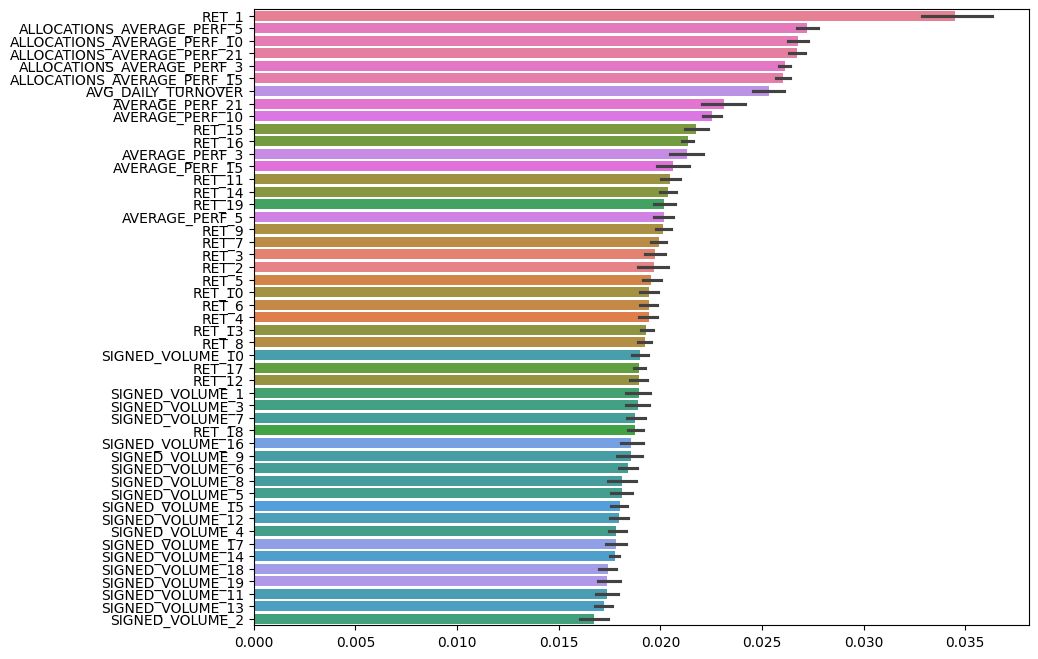

In [124]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)
plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)



1 model per allocation 

In [130]:
y_train_binary

ROW_ID
0         1
1         0
2         1
3         0
4         0
         ..
180240    0
180241    1
180242    0
180243    1
180244    1
Name: target, Length: 180245, dtype: int64

In [146]:
allocs = X_train["ALLOCATION"].unique()

models = {}
scores = {}
for a in allocs : 

    idx_a = X_train['ALLOCATION'] == a
    x_tr, x_val, y_tr, y_val = train_test_split(X_train.loc[idx_a, features], y_train_binary[idx_a], test_size=0.2, random_state=42)


    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models[a] = clf
    scores[a] = acc
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))
    print(f"Allocation {a} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(list(scores.values()))*100
std = np.std(list(scores.values()))*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Allocation ALLOCATION_01 - Acc: 55.50% | best_iter=16 | best_logloss=0.6889792865461057
Allocation ALLOCATION_02 - Acc: 47.57% | best_iter=1 | best_logloss=0.6977850715319316
Allocation ALLOCATION_03 - Acc: 54.41% | best_iter=7 | best_logloss=0.6898080947162869
Allocation ALLOCATION_04 - Acc: 51.35% | best_iter=7 | best_logloss=0.692889999806344
Allocation ALLOCATION_05 - Acc: 54.77% | best_iter=4 | best_logloss=0.6878608860411085
Allocation ALLOCATION_06 - Acc: 49.37% | best_iter=0 | best_logloss=0.6933268621161177
Allocation ALLOCATION_07 - Acc: 55.32% | best_iter=16 | best_logloss=0.6888849970993695
Allocation ALLOCATION_08 - Acc: 54.77% | best_iter=11 | best_logloss=0.6872235489321185
Allocation ALLOCATION_09 - Acc: 52.97% | best_iter=33 | best_logloss=0.6910995626234794
Allocation ALLOCATION_10 - Acc: 53.51% | best_iter=8 | best_logloss=0.6896624637079668
Allocation ALLOCATION_11 - Acc: 53.51% | best_iter=9 | best_logloss=0.6912628684494947
Allocation ALLOCATION_12 - Acc: 53.33% |

<Axes: >

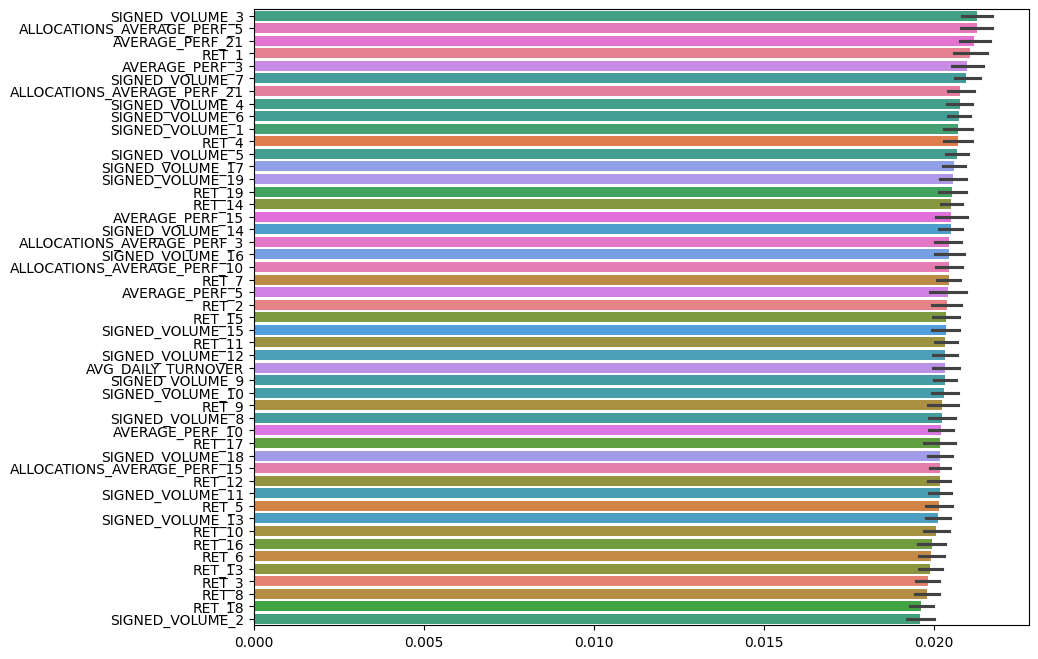

In [176]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models.values()], columns=features)
plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)


In [149]:
df = pd.DataFrame(list(scores.items()), columns=["alloc", "score"])
df["rank"] = df["score"].rank(pct=True)

# top et bottom quantiles (ex: 10%)
q = 0.20
top = df[df["rank"] >= 1 - q].sort_values("score", ascending=False)
bottom = df[df["rank"] <= q].sort_values("score", ascending=True)

print("Top", q * 100, "%")
print(top)
print("Bottom", q * 100, "%")
print(bottom)


Top 20.0 %
            alloc     score      rank
49  ALLOCATION_50  0.590991  0.992308
60  ALLOCATION_61  0.590991  0.992308
23  ALLOCATION_24  0.585586  0.969231
62  ALLOCATION_63  0.583784  0.953846
55  ALLOCATION_56  0.580180  0.938462
64  ALLOCATION_65  0.578378  0.923077
37  ALLOCATION_38  0.571171  0.907692
47  ALLOCATION_48  0.569369  0.892308
22  ALLOCATION_23  0.562162  0.876923
52  ALLOCATION_53  0.560360  0.861538
57  ALLOCATION_58  0.558559  0.846154
33  ALLOCATION_34  0.556757  0.830769
0   ALLOCATION_01  0.554955  0.800000
29  ALLOCATION_30  0.554955  0.800000
35  ALLOCATION_36  0.554955  0.800000
Bottom 20.0 %
            alloc     score      rank
51  ALLOCATION_52  0.464865  0.015385
1   ALLOCATION_02  0.475676  0.030769
59  ALLOCATION_60  0.479279  0.046154
30  ALLOCATION_31  0.490090  0.061538
5   ALLOCATION_06  0.493694  0.076923
16  ALLOCATION_17  0.495495  0.092308
24  ALLOCATION_25  0.497297  0.107692
21  ALLOCATION_22  0.499099  0.130769
34  ALLOCATION_35  0.4990

In [157]:
model_top = models["ALLOCATION_50"]

idx = X_train["ALLOCATION"] == "ALLOCATION_34"
pred_17 = model_top.predict(X_train.loc[idx, features])

acc = accuracy_score(y_train_binary.loc[idx], pred_17)

print(acc)

0.49116480346195457


ALLOCATION_01 -> ALLOCATION_01: 0.7291741795888929
ALLOCATION_01 -> ALLOCATION_02: 0.4990984493328525
ALLOCATION_01 -> ALLOCATION_03: 0.5452578434908042
ALLOCATION_01 -> ALLOCATION_04: 0.47962495492246665
ALLOCATION_01 -> ALLOCATION_05: 0.47962495492246665
ALLOCATION_01 -> ALLOCATION_06: 0.5120807789397764
ALLOCATION_01 -> ALLOCATION_07: 0.4969347277316985
ALLOCATION_01 -> ALLOCATION_08: 0.5207356653443923
ALLOCATION_01 -> ALLOCATION_09: 0.5077533357374684
ALLOCATION_01 -> ALLOCATION_10: 0.5279480706815723
ALLOCATION_01 -> ALLOCATION_11: 0.4890010818608006
ALLOCATION_01 -> ALLOCATION_12: 0.4846736386584926
ALLOCATION_01 -> ALLOCATION_13: 0.5070320952037505
ALLOCATION_01 -> ALLOCATION_14: 0.47962495492246665
ALLOCATION_01 -> ALLOCATION_15: 0.5109989181391994
ALLOCATION_01 -> ALLOCATION_16: 0.4850342589253516
ALLOCATION_01 -> ALLOCATION_17: 0.4944103858636855
ALLOCATION_01 -> ALLOCATION_18: 0.5063108546700325
ALLOCATION_01 -> ALLOCATION_19: 0.4882798413270826
ALLOCATION_01 -> ALLOCATION_

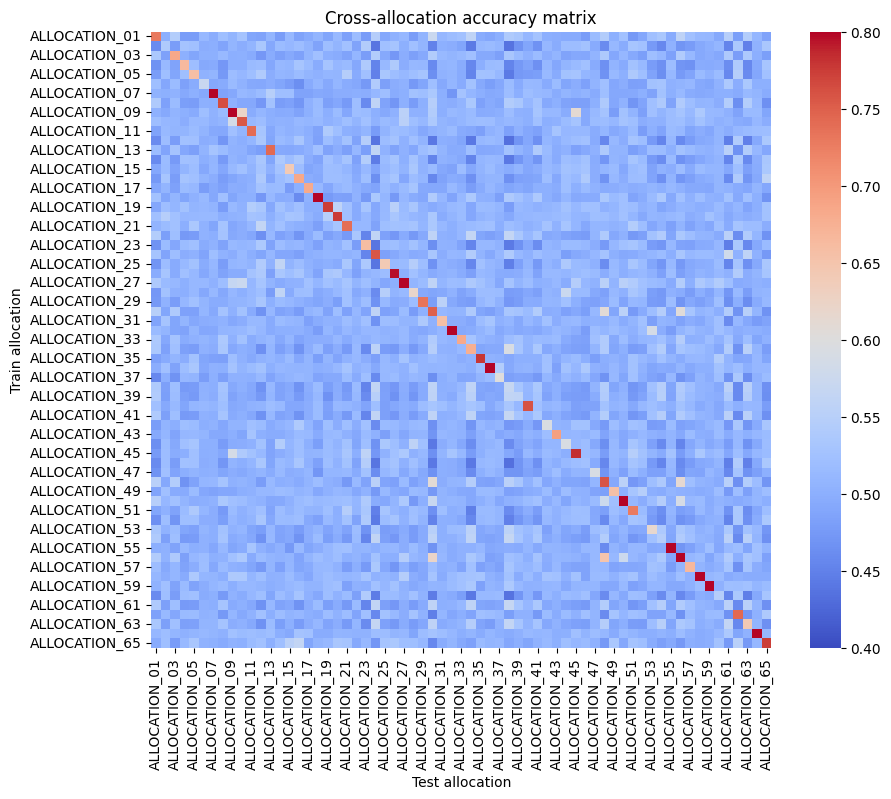

In [159]:
allocs = list(models.keys())
M = pd.DataFrame(index=allocs, columns=allocs, dtype=float)

for i in allocs:
    model_ = models[i]

    for j in allocs:
    
        idx = X_train["ALLOCATION"] == j

        Xj = X_train.loc[idx, features]
        yj = y_train_binary.loc[idx]
        
        p = models[i].predict(Xj)

        acc = accuracy_score(yj, p)
        print(f"{i} -> {j}: {acc}")
        M.loc[i,j] = acc


plt.figure(figsize=(10,8))
sns.heatmap(M, cmap="coolwarm", vmin=0.4, vmax=0.8, annot=False)
plt.title("Cross-allocation accuracy matrix")
plt.xlabel("Test allocation")
plt.ylabel("Train allocation")
plt.show()

In [164]:
M

,ALLOCATION_01,ALLOCATION_02,ALLOCATION_03,ALLOCATION_04,ALLOCATION_05,ALLOCATION_06,ALLOCATION_07,ALLOCATION_08,ALLOCATION_09,ALLOCATION_10,...,ALLOCATION_56,ALLOCATION_57,ALLOCATION_58,ALLOCATION_59,ALLOCATION_60,ALLOCATION_61,ALLOCATION_62,ALLOCATION_63,ALLOCATION_64,ALLOCATION_65
ALLOCATION_01,0.729174,0.499098,0.545258,0.479625,0.479625,0.512081,0.496935,0.520736,0.507753,0.527948,...,0.556437,0.522899,0.511720,0.509556,0.492607,0.547422,0.480707,0.544176,0.508114,0.484674
ALLOCATION_02,0.460873,0.540209,0.478904,0.526866,0.523260,0.496935,0.499459,0.486837,0.506311,0.497295,...,0.469167,0.477101,0.492607,0.499098,0.508475,0.451857,0.535160,0.448972,0.504147,0.533718
ALLOCATION_03,0.534439,0.484313,0.685179,0.500180,0.488640,0.500902,0.500180,0.513163,0.498738,0.500180,...,0.542012,0.511720,0.493689,0.496935,0.491886,0.538767,0.479625,0.536603,0.498738,0.479986
ALLOCATION_04,0.466643,0.512802,0.485034,0.665344,0.518933,0.493689,0.494050,0.472052,0.499459,0.499459,...,0.469888,0.466282,0.496213,0.495132,0.498377,0.461594,0.540570,0.457627,0.492968,0.530112
ALLOCATION_05,0.478182,0.520375,0.488280,0.520375,0.656690,0.503426,0.506311,0.474937,0.517490,0.509556,...,0.476379,0.486837,0.514966,0.504147,0.515687,0.456545,0.548143,0.460512,0.490083,0.524342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ALLOCATION_61,0.540570,0.481428,0.521457,0.475658,0.477461,0.501983,0.499098,0.529391,0.494050,0.501262,...,0.541652,0.522899,0.506311,0.503787,0.493689,0.552831,0.458709,0.550307,0.507032,0.464479
ALLOCATION_62,0.483592,0.512802,0.490083,0.514605,0.516048,0.503787,0.505950,0.474216,0.508114,0.492607,...,0.466282,0.514245,0.502344,0.514966,0.516769,0.465921,0.743238,0.473134,0.501623,0.538406
ALLOCATION_63,0.534079,0.482510,0.522178,0.481789,0.484313,0.507393,0.506311,0.527948,0.496935,0.502344,...,0.536603,0.527587,0.499459,0.505229,0.495853,0.563649,0.457627,0.642265,0.507753,0.464840
ALLOCATION_64,0.510638,0.520014,0.509196,0.501623,0.507393,0.511720,0.506671,0.502344,0.524702,0.515687,...,0.517851,0.503787,0.496574,0.498738,0.510638,0.536603,0.488640,0.504508,0.825820,0.510999


In [165]:
p={'q':0.3}  # fraction of worst allocs to replace (e.g., 0.2~0.3)

base = pd.Series(scores).astype(float)
worst = base.nsmallest(int(np.ceil(len(base)*p['q']))).index

M2 = M.copy()
np.fill_diagonal(M2.values, np.nan)  # exclude self model

best_model_for = M2.loc[:, worst].idxmax(axis=0)      # best training alloc per weak test alloc
best_score_for = M2.loc[:, worst].max(axis=0)         # corresponding scores

score_bis = base.copy()
score_bis.loc[worst] = best_score_for                 # updated scores
# optional dicts
score_bis = score_bis.to_dict()
best_model_for = best_model_for.to_dict()

In [170]:
print(f"mean score of score_bis is {np.array(list(score_bis.values())).mean()}")


mean score of score_bis is 0.5449851815809263


In [172]:
model_map = {a : a for a in allocs}

for i in best_model_for.keys():
    model_map[i] = best_model_for[i]

model_map

    

{'ALLOCATION_01': 'ALLOCATION_01',
 'ALLOCATION_02': 'ALLOCATION_20',
 'ALLOCATION_03': 'ALLOCATION_03',
 'ALLOCATION_04': 'ALLOCATION_16',
 'ALLOCATION_05': 'ALLOCATION_05',
 'ALLOCATION_06': 'ALLOCATION_09',
 'ALLOCATION_07': 'ALLOCATION_07',
 'ALLOCATION_08': 'ALLOCATION_08',
 'ALLOCATION_09': 'ALLOCATION_09',
 'ALLOCATION_10': 'ALLOCATION_10',
 'ALLOCATION_11': 'ALLOCATION_11',
 'ALLOCATION_12': 'ALLOCATION_12',
 'ALLOCATION_13': 'ALLOCATION_13',
 'ALLOCATION_14': 'ALLOCATION_25',
 'ALLOCATION_15': 'ALLOCATION_15',
 'ALLOCATION_16': 'ALLOCATION_16',
 'ALLOCATION_17': 'ALLOCATION_64',
 'ALLOCATION_18': 'ALLOCATION_18',
 'ALLOCATION_19': 'ALLOCATION_20',
 'ALLOCATION_20': 'ALLOCATION_19',
 'ALLOCATION_21': 'ALLOCATION_21',
 'ALLOCATION_22': 'ALLOCATION_08',
 'ALLOCATION_23': 'ALLOCATION_23',
 'ALLOCATION_24': 'ALLOCATION_24',
 'ALLOCATION_25': 'ALLOCATION_28',
 'ALLOCATION_26': 'ALLOCATION_19',
 'ALLOCATION_27': 'ALLOCATION_27',
 'ALLOCATION_28': 'ALLOCATION_44',
 'ALLOCATION_29': 'A

In [177]:
X_test

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,AVERAGE_PERF_3,ALLOCATIONS_AVERAGE_PERF_3,AVERAGE_PERF_5,ALLOCATIONS_AVERAGE_PERF_5,AVERAGE_PERF_10,ALLOCATIONS_AVERAGE_PERF_10,AVERAGE_PERF_15,ALLOCATIONS_AVERAGE_PERF_15,AVERAGE_PERF_21,ALLOCATIONS_AVERAGE_PERF_21
ROW_ID,,,,,,,,,,,,,,,,,,,,,
180245,DATE_2774,ALLOCATION_01,-0.006869,-0.001703,-0.003348,-0.003129,-0.003368,-0.002515,-0.001182,-0.005291,...,-0.004899,0.000107,-0.000539,0.000296,-0.001370,0.000058,-0.001531,-0.000069,-0.001816,-0.000002
180246,DATE_2774,ALLOCATION_02,-0.002409,-0.000763,0.001349,-0.002069,-0.000147,0.002263,-0.004348,-0.006099,...,0.001462,0.000107,0.001239,0.000296,-0.000026,0.000058,-0.000249,-0.000069,-0.000283,-0.000002
180247,DATE_2774,ALLOCATION_03,-0.004936,-0.001041,-0.004108,-0.002354,-0.003627,0.000263,0.001072,-0.007175,...,-0.002155,0.000107,0.000007,0.000296,-0.000835,0.000058,-0.000994,-0.000069,-0.001370,-0.000002
180248,DATE_2774,ALLOCATION_04,-0.008992,-0.000644,0.001352,-0.004524,-0.004002,-0.004404,0.000524,-0.002477,...,-0.005796,0.000107,-0.001085,0.000296,-0.001898,0.000058,-0.001519,-0.000069,-0.001611,-0.000002
180249,DATE_2774,ALLOCATION_05,-0.002797,-0.001686,0.002453,-0.000645,0.000615,-0.000624,-0.004374,-0.003674,...,-0.001748,0.000107,0.000212,0.000296,-0.000494,0.000058,-0.000858,-0.000069,-0.000638,-0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187975,DATE_2892,ALLOCATION_61,0.000898,0.001406,0.001291,0.001114,0.001156,-0.001011,-0.000071,-0.002158,...,0.001907,-0.001547,0.000535,-0.000744,0.000704,-0.000674,0.000534,-0.000591,0.000683,-0.000432
187976,DATE_2892,ALLOCATION_62,0.009038,-0.004750,-0.006179,0.004015,-0.003810,0.003246,-0.003156,0.006477,...,-0.001487,-0.001547,0.000312,-0.000744,-0.002408,-0.000674,-0.002768,-0.000591,-0.002749,-0.000432
187977,DATE_2892,ALLOCATION_63,-0.002501,0.002821,0.003469,0.000963,0.004153,-0.001142,0.001950,-0.002540,...,0.002067,-0.001547,-0.000026,-0.000744,-0.000110,-0.000674,0.000107,-0.000591,0.000685,-0.000432


In [179]:
mk = X_test['ALLOCATION'].map(model_map)                             # alloc -> alloc_ (clé du modèle)
mk

ROW_ID
180245    ALLOCATION_01
180246    ALLOCATION_20
180247    ALLOCATION_03
180248    ALLOCATION_16
180249    ALLOCATION_05
              ...      
187975    ALLOCATION_61
187976    ALLOCATION_62
187977    ALLOCATION_63
187978    ALLOCATION_64
187979    ALLOCATION_65
Name: ALLOCATION, Length: 7735, dtype: object

In [181]:
models

{'ALLOCATION_01': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=100,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=5000, n_jobs=-1,
               num_parallel_tree=None, ...),
 'ALLOCATION_02': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_

In [184]:
pred = pd.Series(index=X_test.index, dtype=float)
for k, idx in mk.groupby(mk).groups.items():              
    pred.loc[list(idx)] = models[k].predict(X_test.loc[list(idx), features])

Y_pred = pred.to_frame('prediction')    
Y_pred['prediction'] = Y_pred['prediction'].astype(int)

In [185]:
Y_pred.to_csv("data/optimized_xgb_per_alloc.csv")

## Per alloc with proper TTS 

In [187]:
idx_01 = X_train['ALLOCATION'] == 'ALLOCATION_01'

X_train.loc[idx_01]

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,AVERAGE_PERF_3,ALLOCATIONS_AVERAGE_PERF_3,AVERAGE_PERF_5,ALLOCATIONS_AVERAGE_PERF_5,AVERAGE_PERF_10,ALLOCATIONS_AVERAGE_PERF_10,AVERAGE_PERF_15,ALLOCATIONS_AVERAGE_PERF_15,AVERAGE_PERF_21,ALLOCATIONS_AVERAGE_PERF_21
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.002477,0.004826,0.005374,-0.001688,-0.000152,-0.000685,-0.002217,0.001911,...,-0.000206,0.000443,-0.000041,0.000157,0.000449,0.000238,0.000085,0.000342,0.000507,0.000087
65,DATE_0002,ALLOCATION_01,0.001084,-0.000758,0.000815,0.002089,-0.000429,-0.000346,-0.000023,-0.003146,...,0.000368,0.000181,0.000178,-0.000011,0.000893,-0.000062,0.000294,-0.000055,0.000323,0.000014
130,DATE_0003,ALLOCATION_01,0.000297,0.000459,-0.000377,0.000143,0.001427,-0.000184,0.000678,0.001583,...,0.000454,-0.000074,0.000733,-0.000131,0.000298,0.000087,0.000319,0.000061,0.000339,0.000061
195,DATE_0004,ALLOCATION_01,-0.002337,-0.000141,-0.000408,-0.002548,-0.002352,0.001243,-0.000483,-0.000726,...,0.001566,0.000096,0.000418,0.000136,0.000257,-0.000056,0.000291,-0.000039,-0.000057,-0.000019
260,DATE_0005,ALLOCATION_01,0.000912,0.004709,0.002465,0.000753,-0.001196,0.002533,-0.004942,-0.010304,...,-0.000494,-0.000020,-0.001304,0.000125,0.000087,-0.000312,-0.000460,-0.000181,-0.000009,-0.000291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179920,DATE_2769,ALLOCATION_01,0.000406,-0.000392,0.002021,0.001724,0.001946,0.002181,-0.000089,-0.000850,...,0.001401,0.000247,0.000941,0.000133,0.000384,0.000141,0.000343,0.000028,0.000550,0.000040
179985,DATE_2770,ALLOCATION_01,0.002237,-0.000796,0.000446,-0.001152,0.003465,0.005692,0.002487,0.001630,...,0.000044,0.000098,-0.000447,0.000054,0.000558,0.000239,0.001051,0.000242,0.000933,0.000177
180050,DATE_2771,ALLOCATION_01,-0.002046,0.001583,0.002405,-0.000147,-0.002158,0.001787,-0.003884,0.002502,...,-0.002142,0.001591,0.000117,0.000069,0.000807,-0.000194,0.000819,-0.000020,0.000735,0.000084


In [188]:
allocs = X_train["ALLOCATION"].unique()

models = {}
scores = {}
for a in allocs : 

    idx_a = X_train['ALLOCATION'] == a
    x_tr, x_val, y_tr, y_val = train_test_split(X_train.loc[idx_a, features], y_train_binary[idx_a], test_size=0.2, random_state=42)


    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models[a] = clf
    scores[a] = acc
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))
    print(f"Allocation {a} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(list(scores.values()))*100
std = np.std(list(scores.values()))*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Allocation ALLOCATION_01 - Acc: 55.50% | best_iter=16 | best_logloss=0.6889792865461057
Allocation ALLOCATION_02 - Acc: 47.57% | best_iter=1 | best_logloss=0.6977850715319316
Allocation ALLOCATION_03 - Acc: 54.41% | best_iter=7 | best_logloss=0.6898080947162869
Allocation ALLOCATION_04 - Acc: 51.35% | best_iter=7 | best_logloss=0.692889999806344
Allocation ALLOCATION_05 - Acc: 54.77% | best_iter=4 | best_logloss=0.6878608860411085
Allocation ALLOCATION_06 - Acc: 49.37% | best_iter=0 | best_logloss=0.6933268621161177
Allocation ALLOCATION_07 - Acc: 55.32% | best_iter=16 | best_logloss=0.6888849970993695
Allocation ALLOCATION_08 - Acc: 54.77% | best_iter=11 | best_logloss=0.6872235489321185
Allocation ALLOCATION_09 - Acc: 52.97% | best_iter=33 | best_logloss=0.6910995626234794
Allocation ALLOCATION_10 - Acc: 53.51% | best_iter=8 | best_logloss=0.6896624637079668
Allocation ALLOCATION_11 - Acc: 53.51% | best_iter=9 | best_logloss=0.6912628684494947
Allocation ALLOCATION_12 - Acc: 53.33% |